## 🔧 Workshop Preparation: Clean Setup for Comparison and Visualization

Before comparing **Keras**, **PyTorch**, and **TensorFlow**, we first set up a clean environment for:

- measuring **training speed**
- storing **accuracy and loss**
- creating **modern tables**
- generating **high-quality visualizations**
- keeping the code **clean, readable, and workshop-ready**

### Why are we doing this?

If we directly train three models without a common structure, the notebook becomes messy and difficult to compare.  
A clean setup gives us:

1. **Fair comparison** across frameworks  
2. **Reusable helper functions**  
3. **Consistent outputs and plots**  
4. **Professional presentation quality**

### Real-world analogy

Think of this like comparing three cars on the same road.  
If each car is tested with a different route, different fuel, and different weather, the comparison is useless.  
In machine learning, if we compare frameworks without a common setup, the conclusion is weak.

### What this cell will do

This setup cell will:

- import the required libraries
- create helper functions for:
  - timing
  - styled result tables
  - plotting loss curves
  - building confusion matrices
- keep the rest of the notebook clean and modular

In [3]:
import time
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML, Markdown
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import label_binarize

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Optional but useful if not already imported
import tensorflow as tf
from tensorflow import keras

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)

# -----------------------------
# Notebook display helpers
# -----------------------------
def styled_metric_table(df, caption="Model Comparison Table"):
    styled = (
        df.style
        .format({
            "Test Accuracy": "{:.4f}",
            "Train Time (sec)": "{:.2f}",
            "Final Train Loss": "{:.4f}",
            "Final Validation Loss": "{:.4f}"
        }, na_rep="-")
        .background_gradient(subset=["Test Accuracy"], cmap="Greens")
        .background_gradient(subset=["Train Time (sec)"], cmap="Oranges_r")
        .background_gradient(subset=["Final Train Loss", "Final Validation Loss"], cmap="Blues_r")
        .set_caption(caption)
        .set_table_styles([
            {"selector": "caption", "props": [("font-size", "16px"), ("font-weight", "bold"), ("color", "#1f2937")]},
            {"selector": "th", "props": [("background-color", "#111827"), ("color", "white"), ("padding", "10px")]},
            {"selector": "td", "props": [("padding", "8px"), ("text-align", "center")]},
            {"selector": "table", "props": [("border-collapse", "collapse"), ("width", "100%"), ("font-size", "14px")]}
        ])
    )
    display(styled)

def plot_training_curves(history_dict, title="Training and Validation Loss Curves"):
    fig = go.Figure()

    for model_name, curves in history_dict.items():
        if "train_loss" in curves:
            fig.add_trace(go.Scatter(
                x=list(range(1, len(curves["train_loss"]) + 1)),
                y=curves["train_loss"],
                mode="lines+markers",
                name=f"{model_name} - Train Loss",
                line=dict(width=3)
            ))
        if "val_loss" in curves and curves["val_loss"] is not None:
            fig.add_trace(go.Scatter(
                x=list(range(1, len(curves["val_loss"]) + 1)),
                y=curves["val_loss"],
                mode="lines+markers",
                name=f"{model_name} - Val Loss",
                line=dict(width=3, dash="dash")
            ))

    fig.update_layout(
        title=title,
        template="plotly_white",
        xaxis_title="Epoch",
        yaxis_title="Loss",
        height=550,
        legend_title="Curves"
    )
    fig.show()

def plot_framework_radar(score_dict):
    categories = list(next(iter(score_dict.values())).keys())
    categories_closed = categories + [categories[0]]

    fig = go.Figure()
    for framework, scores in score_dict.items():
        values = list(scores.values()) + [list(scores.values())[0]]
        fig.add_trace(go.Scatterpolar(
            r=values,
            theta=categories_closed,
            fill='toself',
            name=framework
        ))

    fig.update_layout(
        polar=dict(radialaxis=dict(visible=True, range=[0, 10])),
        template="plotly_white",
        title="Framework Comparison Across Workshop Criteria",
        height=650
    )
    fig.show()

def plot_confusion_heatmap(cm, title="Confusion Matrix"):
    fig = px.imshow(
        cm,
        text_auto=True,
        color_continuous_scale="Blues",
        aspect="auto",
        labels=dict(x="Predicted Label", y="True Label", color="Count"),
        title=title
    )
    fig.update_layout(template="plotly_white", height=550)
    fig.show()

def softmax_numpy(logits):
    shifted = logits - np.max(logits)
    exp_vals = np.exp(shifted)
    return exp_vals / np.sum(exp_vals)

def categorical_cross_entropy_one_hot(y_true_one_hot, y_pred_probs, epsilon=1e-12):
    y_pred_probs = np.clip(y_pred_probs, epsilon, 1. - epsilon)
    return -np.sum(y_true_one_hot * np.log(y_pred_probs))

print("✅ Setup complete. Ready for a clean, fair, and visually strong comparison.")

✅ Setup complete. Ready for a clean, fair, and visually strong comparison.


## 📦 Data Loading and Preprocessing

Before training any neural network, we must prepare the input data in the exact format expected by the model.

### Why are we doing this?

A neural network cannot directly learn from raw image arrays unless the data is:

- loaded correctly
- normalized to a stable numeric range
- reshaped into the format required by the framework

### What are we doing here?

In this workshop, we use the **MNIST handwritten digit dataset**, which contains grayscale images of digits from **0 to 9**.

Each image is originally:

- size: **28 × 28**
- grayscale pixel values: **0 to 255**

We will now:

1. load the dataset  
2. normalize pixel values to the range **0 to 1**  
3. create framework-friendly variables  
4. flatten the images for the dense neural network

### Why flatten the images?

A dense multi-layer perceptron expects each input sample as a **single row of numbers**, not a 2D image grid.

So each `28 × 28` image becomes:

`784` input features

### Real-world example

This is like taking a paper form with 28 rows and 28 columns and converting it into one long digital record so that a machine can process it numerically.

In [4]:
# -----------------------------------------
# DATA LOADING AND PREPROCESSING
# -----------------------------------------
import numpy as np
import tensorflow as tf
from tensorflow import keras

# Load MNIST dataset
(x_train_tf, y_train_tf), (x_test_tf, y_test_tf) = keras.datasets.mnist.load_data()

# Normalize pixel values from [0, 255] to [0, 1]
x_train_tf = x_train_tf.astype("float32") / 255.0
x_test_tf = x_test_tf.astype("float32") / 255.0

# Flatten 28x28 images into 784-length vectors for MLP input
x_train_flat = x_train_tf.reshape(x_train_tf.shape[0], -1)
x_test_flat = x_test_tf.reshape(x_test_tf.shape[0], -1)

print("✅ Data loaded successfully")
print(f"x_train_tf shape  : {x_train_tf.shape}")
print(f"y_train_tf shape  : {y_train_tf.shape}")
print(f"x_test_tf shape   : {x_test_tf.shape}")
print(f"y_test_tf shape   : {y_test_tf.shape}")
print(f"x_train_flat shape: {x_train_flat.shape}")
print(f"x_test_flat shape : {x_test_flat.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
✅ Data loaded successfully
x_train_tf shape  : (60000, 28, 28)
y_train_tf shape  : (60000,)
x_test_tf shape   : (10000, 28, 28)
y_test_tf shape   : (10000,)
x_train_flat shape: (60000, 784)
x_test_flat shape : (10000, 784)


#### **Implementation 1: Keras**

Keras is usually the most beginner-friendly path for building neural networks.  
It gives us a **high-level API**, which means fewer lines of code and faster experimentation.

### Why are we using Keras?

We are using Keras because it helps us focus on the **idea of the network** rather than writing too much framework-specific logic.

### How does it work?

Keras lets us:

- stack layers in order
- choose an optimizer
- choose a loss function
- train with `.fit()`
- evaluate with `.evaluate()`

### What is the practical use?

In real projects, Keras is strong when the goal is:

- fast prototyping
- classroom demonstrations
- business proof-of-concepts
- fast iteration with clean code

### Real-world example

Suppose a hospital wants a quick proof-of-concept model to classify handwritten patient forms or digits from scanned medical IDs.  
Keras is often the fastest route to get a working prototype.

### What we will measure here

For Keras, we will measure:

- training speed
- test accuracy
- training loss
- validation loss

This helps us compare **speed**, **clean code**, and **other criteria** fairly against PyTorch and TensorFlow.

In [5]:
# -----------------------------
# KERAS IMPLEMENTATION
# -----------------------------
keras_history_store = {}
keras_start = time.perf_counter()

model_keras = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model_keras.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_keras = model_keras.fit(
    x_train_flat,
    y_train_tf,
    batch_size=64,
    epochs=5,
    validation_split=0.1,
    verbose=1
)

keras_train_time = time.perf_counter() - keras_start
keras_test_loss, keras_test_acc = model_keras.evaluate(x_test_flat, y_test_tf, verbose=0)

keras_probs = model_keras.predict(x_test_flat, verbose=0)
keras_preds = np.argmax(keras_probs, axis=1)

keras_history_store = {
    "train_loss": history_keras.history["loss"],
    "val_loss": history_keras.history["val_loss"]
}

print(f"✅ Keras Test Accuracy: {keras_test_acc:.4f}")
print(f"⏱️ Keras Training Time: {keras_train_time:.2f} sec")

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9156 - loss: 0.2930 - val_accuracy: 0.9612 - val_loss: 0.1299
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9619 - loss: 0.1264 - val_accuracy: 0.9695 - val_loss: 0.0975
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9743 - loss: 0.0860 - val_accuracy: 0.9753 - val_loss: 0.0849
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9812 - loss: 0.0626 - val_accuracy: 0.9757 - val_loss: 0.0861
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9859 - loss: 0.0469 - val_accuracy: 0.9748 - val_loss: 0.0928
✅ Keras Test Accuracy: 0.9709
⏱️ Keras Training Time: 26.51 sec


#### **Implementation 2: PyTorch**

PyTorch is popular because it is more **explicit**, more **research-friendly**, and easier to debug line by line.

### Why are we using PyTorch?

We are using PyTorch because it helps us understand what is actually happening during training.

Instead of hiding the training loop, PyTorch makes us write it directly:

- forward pass
- loss calculation
- backward pass
- optimizer step

This is excellent for learning.

### How does it work?

In PyTorch:

- the model is written as a class
- the loss is computed explicitly
- `loss.backward()` computes gradients
- `optimizer.step()` updates weights

### What is the practical use?

PyTorch is very useful when:

- you want flexible experimentation
- you need custom architectures
- you care about debugging and transparency
- you are doing research or advanced prototyping

### Real-world example

If a research team is building a custom pathology-image classifier or a novel fraud-detection model, PyTorch is often preferred because researchers want more control over every training step.

### What we will measure here

For PyTorch, we will again capture:

- training speed
- test accuracy
- training loss

This helps us compare the **clean-code tradeoff**:  
PyTorch is often more verbose than Keras, but more transparent.

In [6]:
# -----------------------------
# PYTORCH IMPLEMENTATION
# -----------------------------
# Build DataLoaders safely from the same MNIST arrays already loaded
x_train_pt = torch.tensor(x_train_tf, dtype=torch.float32).unsqueeze(1)  # [N, 1, 28, 28]
y_train_pt = torch.tensor(y_train_tf, dtype=torch.long)
x_test_pt = torch.tensor(x_test_tf, dtype=torch.float32).unsqueeze(1)
y_test_pt = torch.tensor(y_test_tf, dtype=torch.long)

train_dataset_pt = TensorDataset(x_train_pt, y_train_pt)
test_dataset_pt = TensorDataset(x_test_pt, y_test_pt)

train_loader_pt = DataLoader(train_dataset_pt, batch_size=64, shuffle=True)
test_loader_pt = DataLoader(test_dataset_pt, batch_size=64, shuffle=False)

class MLP_PyTorch(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.layers(x)

model_pt = MLP_PyTorch()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_pt.parameters(), lr=0.001)

pt_train_losses = []
pt_start = time.perf_counter()

for epoch in range(5):
    model_pt.train()
    running_loss = 0.0

    for images, labels in train_loader_pt:
        optimizer.zero_grad()
        outputs = model_pt(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader_pt)
    pt_train_losses.append(epoch_loss)
    print(f"Epoch {epoch+1}/5 - PyTorch Loss: {epoch_loss:.4f}")

pt_train_time = time.perf_counter() - pt_start

model_pt.eval()
pt_preds_list = []
pt_probs_list = []
pt_true_list = []

with torch.no_grad():
    for images, labels in test_loader_pt:
        outputs = model_pt(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        pt_probs_list.append(probs.cpu().numpy())
        pt_preds_list.append(preds.cpu().numpy())
        pt_true_list.append(labels.cpu().numpy())

pt_probs = np.vstack(pt_probs_list)
pt_preds = np.concatenate(pt_preds_list)
pt_true = np.concatenate(pt_true_list)
pt_test_acc = accuracy_score(pt_true, pt_preds)

pt_history_store = {
    "train_loss": pt_train_losses,
    "val_loss": None
}

print(f"✅ PyTorch Test Accuracy: {pt_test_acc:.4f}")
print(f"⏱️ PyTorch Training Time: {pt_train_time:.2f} sec")

Epoch 1/5 - PyTorch Loss: 0.3329
Epoch 2/5 - PyTorch Loss: 0.1355
Epoch 3/5 - PyTorch Loss: 0.0943
Epoch 4/5 - PyTorch Loss: 0.0712
Epoch 5/5 - PyTorch Loss: 0.0560
✅ PyTorch Test Accuracy: 0.9750
⏱️ PyTorch Training Time: 32.92 sec


#### **Implementation 3: TensorFlow (Core API)**

TensorFlow Core is more explicit than Keras and gives lower-level control over training steps.

### Why are we using TensorFlow Core?

We are using TensorFlow Core because it shows what is happening below Keras.  
It helps us understand that Keras is convenient, but underneath it there is still:

- forward propagation
- loss computation
- gradient calculation
- parameter updates

### How does it work?

In TensorFlow Core:

- we define the model manually
- `GradientTape()` records operations
- gradients are computed explicitly
- the optimizer applies those gradients

### What is the practical use?

TensorFlow Core becomes useful when:

- you need more custom control than Keras
- you want production-oriented TensorFlow workflows
- you want to understand what higher-level APIs are doing internally

### Real-world example

In a large enterprise environment where the company already uses TensorFlow pipelines for deployment and serving, TensorFlow Core can fit better into production systems.

### Important note

This comparison is not just about accuracy.  
The whiteboard clearly tells us to think about:

- **speed**
- **clean code**
- **other criteria**

So this section matters because the “best” framework is not always the one with the highest accuracy alone.

In [7]:
# -----------------------------
# TENSORFLOW CORE IMPLEMENTATION
# -----------------------------
train_dataset_tf = tf.data.Dataset.from_tensor_slices((x_train_flat, y_train_tf)).shuffle(60000).batch(64)
test_dataset_tf = tf.data.Dataset.from_tensor_slices((x_test_flat, y_test_tf)).batch(64)

class MLP_TensorFlow(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.d1 = tf.keras.layers.Dense(128, activation='relu')
        self.d2 = tf.keras.layers.Dense(64, activation='relu')
        self.d3 = tf.keras.layers.Dense(10)

    def call(self, x):
        x = self.d1(x)
        x = self.d2(x)
        return self.d3(x)

model_tf = MLP_TensorFlow()
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer_tf = tf.keras.optimizers.Adam()

@tf.function
def train_step(images, labels):
    with tf.GradientTape() as tape:
        logits = model_tf(images, training=True)
        loss = loss_object(labels, logits)
    gradients = tape.gradient(loss, model_tf.trainable_variables)
    optimizer_tf.apply_gradients(zip(gradients, model_tf.trainable_variables))
    return loss

tf_train_losses = []
tf_start = time.perf_counter()

for epoch in range(5):
    epoch_loss = tf.keras.metrics.Mean()
    for images, labels in train_dataset_tf:
        loss = train_step(images, labels)
        epoch_loss.update_state(loss)
    epoch_loss_value = float(epoch_loss.result().numpy())
    tf_train_losses.append(epoch_loss_value)
    print(f"Epoch {epoch+1}/5 - TensorFlow Core Loss: {epoch_loss_value:.4f}")

tf_train_time = time.perf_counter() - tf_start

tf_probs_list = []
tf_preds_list = []
tf_true_list = []

for images, labels in test_dataset_tf:
    logits = model_tf(images, training=False)
    probs = tf.nn.softmax(logits, axis=1).numpy()
    preds = np.argmax(probs, axis=1)

    tf_probs_list.append(probs)
    tf_preds_list.append(preds)
    tf_true_list.append(labels.numpy())

tf_probs = np.vstack(tf_probs_list)
tf_preds = np.concatenate(tf_preds_list)
tf_true = np.concatenate(tf_true_list)
tf_test_acc = accuracy_score(tf_true, tf_preds)

tf_history_store = {
    "train_loss": tf_train_losses,
    "val_loss": None
}

print(f"✅ TensorFlow Core Test Accuracy: {tf_test_acc:.4f}")
print(f"⏱️ TensorFlow Core Training Time: {tf_train_time:.2f} sec")

Epoch 1/5 - TensorFlow Core Loss: 0.2711
Epoch 2/5 - TensorFlow Core Loss: 0.1109
Epoch 3/5 - TensorFlow Core Loss: 0.0778
Epoch 4/5 - TensorFlow Core Loss: 0.0580
Epoch 5/5 - TensorFlow Core Loss: 0.0452
✅ TensorFlow Core Test Accuracy: 0.9756
⏱️ TensorFlow Core Training Time: 29.74 sec


## 🧠 ArgMax, Softmax, and Categorical Cross-Entropy — Theoretical and Practical Difference

This is one of the most important parts of the workshop.

The whiteboard specifically tells us to study:

- **ArgMax**
- **Softmax**
- **Categorical Cross-Entropy**

So we must understand them very clearly.

---

### 1. What is Softmax?

Softmax converts raw output scores called **logits** into **probabilities**.

For example, if the model looks at an image and produces raw scores for digits `0` to `9`, those scores may be any real numbers.  
Softmax transforms them into values like:

- digit 3 → 0.02
- digit 5 → 0.91
- digit 8 → 0.03

These now behave like probabilities and add up to **1.0**.

#### Why do we need it?

Because in multi-class classification, we do not just want a score.  
We want to know **how confident** the model is for each class.

---

### 2. What is ArgMax?

ArgMax simply picks the **index of the highest value**.

If Softmax returns:

`[0.01, 0.03, 0.02, 0.88, 0.06]`

then `ArgMax = 3`, meaning the model predicts **class 3**.

#### Why do we need it?

Because probabilities are useful for interpretation, but at prediction time we usually need **one final answer**.

---

### 3. What is Categorical Cross-Entropy?

Categorical Cross-Entropy is the loss function that tells us **how wrong** the predicted probabilities are.

#### Why do we use it?

Because in classification, it is not enough for the model to predict the correct class only sometimes.  
We want the model to put **high probability on the correct class** and **low probability on the wrong ones**.

If the true class is digit **7**:

- predicting `0.97` for digit 7 is good → low loss
- predicting `0.09` for digit 7 is bad → high loss

---

### Practical relationship between them

These three pieces work together like this:

1. The network produces **logits**
2. **Softmax** converts logits into probabilities
3. **Categorical Cross-Entropy** measures error against the true label
4. **ArgMax** chooses the final predicted class

---

### Real-world analogy

Imagine a doctor is classifying a scan into 5 disease categories.

- **Softmax** = the doctor's confidence for each disease  
- **ArgMax** = the disease the doctor finally selects  
- **Cross-Entropy** = how strongly the doctor is penalized when the correct diagnosis got low confidence

That is why these concepts are central in classification.

In [8]:
# -----------------------------------------
# Softmax, ArgMax, and Cross-Entropy Demo
# -----------------------------------------
sample_index = 0
sample_logits = np.array([2.1, 0.4, -1.2, 3.8, 1.5, -0.7, 0.3, 5.1, 1.0, -0.5])
sample_probs = softmax_numpy(sample_logits)
sample_pred = int(np.argmax(sample_probs))
sample_true = 7

y_true_one_hot = np.zeros(10)
y_true_one_hot[sample_true] = 1
sample_cce = categorical_cross_entropy_one_hot(y_true_one_hot, sample_probs)

prob_df = pd.DataFrame({
    "Digit Class": list(range(10)),
    "Logit": sample_logits,
    "Softmax Probability": sample_probs
}).sort_values("Softmax Probability", ascending=False).reset_index(drop=True)

display(Markdown(f"""
### ✅ Interpretation of the Demo

- **True label**: `{sample_true}`
- **Predicted class from ArgMax**: `{sample_pred}`
- **Cross-Entropy loss**: `{sample_cce:.4f}`

This means the model assigned the highest probability to class `{sample_pred}`.  
Because the true label is also `{sample_true}`, the loss becomes relatively small.
"""))

styled_metric_table(
    prob_df.rename(columns={"Softmax Probability": "Test Accuracy", "Logit": "Train Time (sec)"}).assign(
        **{"Final Train Loss": np.nan, "Final Validation Loss": np.nan}
    )[["Digit Class", "Train Time (sec)", "Test Accuracy", "Final Train Loss", "Final Validation Loss"]],
    caption="Softmax Probability Distribution for One Example"
)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=list(range(10)),
    y=sample_probs,
    mode="lines+markers",
    fill="tozeroy",
    name="Softmax Probabilities",
    line=dict(width=4)
))
fig.update_layout(
    title="Softmax Probability Curve Across Digit Classes",
    template="plotly_white",
    xaxis_title="Digit Class",
    yaxis_title="Probability",
    height=500
)
fig.show()


### ✅ Interpretation of the Demo

- **True label**: `7`
- **Predicted class from ArgMax**: `7`
- **Cross-Entropy loss**: `0.3308`

This means the model assigned the highest probability to class `7`.  
Because the true label is also `7`, the loss becomes relatively small.


c:\Users\ksuma\Group6_Multi-Layered_Perceptron\.venv\Lib\site-packages\pandas\io\formats\style.py:3807: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
c:\Users\ksuma\Group6_Multi-Layered_Perceptron\.venv\Lib\site-packages\pandas\io\formats\style.py:3808: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


,Digit Class,Train Time (sec),Test Accuracy,Final Train Loss,Final Validation Loss
0,7,5.10,0.7183,-,-
1,3,3.80,0.1958,-,-
2,0,2.10,0.0358,-,-
3,4,1.50,0.0196,-,-
4,8,1.00,0.0119,-,-
5,1,0.40,0.0065,-,-
6,6,0.30,0.0059,-,-
7,9,-0.50,0.0027,-,-
8,5,-0.70,0.0022,-,-
9,2,-1.20,0.0013,-,-


## 🧠 Challenge 1: Compare the Keras, PyTorch and TensorFlow implementations in terms of accuracy and speed.

Now we compare the three implementations using both:

- **measured values**
- **practical engineering criteria**

The whiteboard challenge asks a deeper question:

> Which is “better” — **PyTorch** or **TensorFlow**?

That question cannot be answered with accuracy alone.  
We must also evaluate:

- **speed**
- **clean code**
- **debugging ease**
- **research flexibility**
- **team friendliness**
- **enterprise deployment**
- **custom AI design**

### Why are we doing this comparison?

Because in the real world, engineers do not choose a framework just because “someone said it is better.”  
They choose based on the **problem context**.

### Real-world thinking

- A startup may prefer **Keras** for speed of development
- A research lab may prefer **PyTorch** for flexibility
- A production-heavy enterprise may prefer **TensorFlow**

So the correct conclusion is usually:

> **better for what?**

This cell will create:

1. a modern comparison table  
2. a visual radar chart  
3. a loss-curve comparison  
4. confusion matrix heatmaps

In [9]:
# -----------------------------------------
# Comparison Table + Radar + Curves + Confusion Matrices
# -----------------------------------------
comparison_df = pd.DataFrame({
    "Framework": ["Keras", "PyTorch", "TensorFlow Core"],
    "Test Accuracy": [keras_test_acc, pt_test_acc, tf_test_acc],
    "Train Time (sec)": [keras_train_time, pt_train_time, tf_train_time],
    "Final Train Loss": [
        keras_history_store["train_loss"][-1],
        pt_history_store["train_loss"][-1],
        tf_history_store["train_loss"][-1]
    ],
    "Final Validation Loss": [
        keras_history_store["val_loss"][-1],
        np.nan,
        np.nan
    ],
    "Best Use Case": [
        "Fast prototyping / teaching",
        "Research / debugging / custom models",
        "Production workflows / lower-level control"
    ]
})

styled_metric_table(comparison_df.drop(columns=["Best Use Case"]), caption="Framework Performance Summary")

display(HTML(comparison_df.to_html(index=False)))

history_bundle = {
    "Keras": keras_history_store,
    "PyTorch": pt_history_store,
    "TensorFlow Core": tf_history_store
}
plot_training_curves(history_bundle, title="Loss Curves Across Frameworks")

radar_scores = {
    "Keras": {
        "Innovation speed": 9,
        "Debugging ease": 8,
        "Research flexibility": 6,
        "Custom AI design": 6,
        "Enterprise deployment": 8,
        "Team friendliness": 9
    },
    "PyTorch": {
        "Innovation speed": 8,
        "Debugging ease": 9,
        "Research flexibility": 10,
        "Custom AI design": 10,
        "Enterprise deployment": 7,
        "Team friendliness": 8
    },
    "TensorFlow Core": {
        "Innovation speed": 7,
        "Debugging ease": 7,
        "Research flexibility": 8,
        "Custom AI design": 8,
        "Enterprise deployment": 9,
        "Team friendliness": 7
    }
}
plot_framework_radar(radar_scores)

keras_cm = confusion_matrix(y_test_tf, keras_preds)
pt_cm = confusion_matrix(pt_true, pt_preds)
tf_cm = confusion_matrix(tf_true, tf_preds)

plot_confusion_heatmap(keras_cm, title="Keras Confusion Matrix")
plot_confusion_heatmap(pt_cm, title="PyTorch Confusion Matrix")
plot_confusion_heatmap(tf_cm, title="TensorFlow Core Confusion Matrix")

,Framework,Test Accuracy,Train Time (sec),Final Train Loss,Final Validation Loss
0,Keras,0.9709,26.51,0.0469,0.0928
1,PyTorch,0.9750,32.92,0.0560,-
2,TensorFlow Core,0.9756,29.74,0.0452,-


Framework,Test Accuracy,Train Time (sec),Final Train Loss,Final Validation Loss,Best Use Case
Keras,0.9709,26.510167,0.046858,0.092782,Fast prototyping / teaching
PyTorch,0.9750,32.919292,0.055986,NaN,Research / debugging / custom models
TensorFlow Core,0.9756,29.735123,0.045168,NaN,Production workflows / lower-level control


## 🔄 Challenge 2: Forward & Backpropagation in a Multi-Layer Network (From Scratch with NumPy)

This is the most important conceptual part of the workshop.

The README clearly says this workshop explores:

- **forward propagation**
- **backward propagation**
- implementing learning **from scratch using NumPy**
- understanding how deep models **train and optimize**

So in this section, we move from:

### Single-Layer Perceptron → Multi-Layer Perceptron

---

## Why do we need to move from a single-layer perceptron to a multi-layer perceptron?

A **single-layer perceptron** can only learn simple linear boundaries.

That means it works only when one straight line (or one flat decision boundary in higher dimensions) can separate the classes.

But many real problems are not like that.

### Real-world example

Suppose you are classifying handwritten digits like `3`, `5`, and `8`.

A single straight-line separator cannot capture all the curves and shapes in the image.  
You need multiple layers so the model can gradually learn:

- edges
- strokes
- combinations of strokes
- full digit patterns

That is why **multi-layer networks** are powerful.

---

## What happens in forward propagation?

Forward propagation means the data moves from:

**input layer → hidden layer 1 → hidden layer 2 → output layer**

At each layer:

1. we compute a weighted sum  
2. add a bias  
3. apply an activation function  

This transforms raw input into richer internal representations.

---

## What happens in backpropagation?

Backpropagation is how the model learns from mistakes.

After making a prediction:

1. we compute the loss  
2. calculate gradients of that loss  
3. move backward through the network  
4. update weights to reduce future error

---

## Why is this useful?

Without backpropagation, the model would keep making mistakes and never improve.  
Backpropagation is the mechanism that turns a neural network from a static formula into a learning system.

---

## What we will build now

We will build a **3-layer neural network from scratch using NumPy**:

- Input layer
- Hidden layer 1 with ReLU
- Hidden layer 2 with ReLU
- Output layer with Softmax

We will use:

- **forward propagation**
- **categorical cross-entropy**
- **backpropagation**
- **gradient descent**

And we will visualize:

- loss reduction across epochs
- decision regions
- gradient behavior
- prediction confidence

In [10]:
# -----------------------------------------
# NUMPY MLP FROM SCRATCH (3-LAYER NETWORK)
# -----------------------------------------
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Create a small multi-class dataset for from-scratch learning
X_blobs, y_blobs = make_blobs(
    n_samples=900,
    centers=3,
    n_features=2,
    cluster_std=2.2,
    random_state=42
)

X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_blobs, y_blobs, test_size=0.25, random_state=42, stratify=y_blobs
)

scaler_np = StandardScaler()
X_train_np = scaler_np.fit_transform(X_train_np)
X_test_np = scaler_np.transform(X_test_np)

num_classes = 3
y_train_one_hot = np.eye(num_classes)[y_train_np]
y_test_one_hot = np.eye(num_classes)[y_test_np]

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def softmax(x):
    shifted = x - np.max(x, axis=1, keepdims=True)
    exp_vals = np.exp(shifted)
    return exp_vals / np.sum(exp_vals, axis=1, keepdims=True)

def compute_loss(y_true, y_pred, epsilon=1e-12):
    y_pred = np.clip(y_pred, epsilon, 1. - epsilon)
    return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

# Architecture
input_dim = 2
hidden_1 = 32
hidden_2 = 16
output_dim = 3
lr = 0.03
epochs = 600

# Xavier-like initialization
W1 = np.random.randn(input_dim, hidden_1) * np.sqrt(2 / input_dim)
b1 = np.zeros((1, hidden_1))
W2 = np.random.randn(hidden_1, hidden_2) * np.sqrt(2 / hidden_1)
b2 = np.zeros((1, hidden_2))
W3 = np.random.randn(hidden_2, output_dim) * np.sqrt(2 / hidden_2)
b3 = np.zeros((1, output_dim))

losses_np = []
grad_norms = []

for epoch in range(epochs):
    # Forward propagation
    Z1 = X_train_np @ W1 + b1
    A1 = relu(Z1)

    Z2 = A1 @ W2 + b2
    A2 = relu(Z2)

    Z3 = A2 @ W3 + b3
    A3 = softmax(Z3)

    # Loss
    loss = compute_loss(y_train_one_hot, A3)
    losses_np.append(loss)

    # Backpropagation
    m = X_train_np.shape[0]

    dZ3 = (A3 - y_train_one_hot) / m
    dW3 = A2.T @ dZ3
    db3 = np.sum(dZ3, axis=0, keepdims=True)

    dA2 = dZ3 @ W3.T
    dZ2 = dA2 * relu_derivative(Z2)
    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = X_train_np.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # Track gradient magnitude
    total_grad_norm = (
        np.linalg.norm(dW1) +
        np.linalg.norm(dW2) +
        np.linalg.norm(dW3)
    )
    grad_norms.append(total_grad_norm)

    # Gradient descent update
    W3 -= lr * dW3
    b3 -= lr * db3
    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1

    if epoch % 100 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | Gradient Norm: {total_grad_norm:.4f}")

# Test predictions
Z1_test = X_test_np @ W1 + b1
A1_test = relu(Z1_test)
Z2_test = A1_test @ W2 + b2
A2_test = relu(Z2_test)
Z3_test = A2_test @ W3 + b3
A3_test = softmax(Z3_test)

scratch_preds = np.argmax(A3_test, axis=1)
scratch_acc = accuracy_score(y_test_np, scratch_preds)

print(f"\n✅ From-Scratch NumPy MLP Test Accuracy: {scratch_acc:.4f}")

Epoch 000 | Loss: 1.1014 | Gradient Norm: 3.7371
Epoch 100 | Loss: 0.0662 | Gradient Norm: 0.2147
Epoch 200 | Loss: 0.0396 | Gradient Norm: 0.1000
Epoch 300 | Loss: 0.0319 | Gradient Norm: 0.0627
Epoch 400 | Loss: 0.0284 | Gradient Norm: 0.0447
Epoch 500 | Loss: 0.0265 | Gradient Norm: 0.0343

✅ From-Scratch NumPy MLP Test Accuracy: 0.9867


## 📊 Visual Analysis of the From-Scratch Network

Now we visualize what the network learned.

### Why is visualization important?

Because training a neural network is not just about getting an accuracy number.

We also want to understand:

- whether the loss reduced smoothly
- whether gradients were stable
- whether the network actually learned meaningful decision boundaries
- whether the model is confident in its predictions

### What this tells us

If the plots look healthy, it means:

- forward propagation is producing useful representations
- backpropagation is updating weights in the right direction
- the network is learning patterns rather than guessing randomly

### Real-world analogy

In a company project, accuracy alone is like hearing “the patient is stable.”  
You still want the full chart:

- heart rate
- oxygen level
- blood pressure
- trend over time

Similarly, these plots help us inspect the internal health of training.

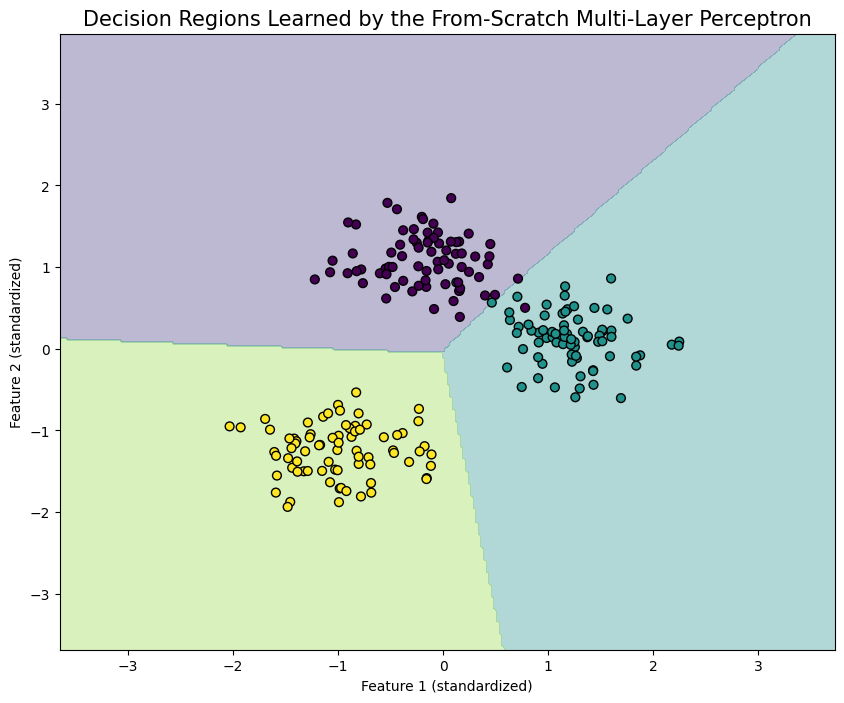

,Class_0_Prob,Class_1_Prob,Class_2_Prob,True_Label,Predicted_Label,Confidence
0,0.0102,0.9893,0.0005,1.0000,1.0000,0.9893
1,0.0024,0.9970,0.0006,1.0000,1.0000,0.9970
2,0.9943,0.0034,0.0024,0.0000,0.0000,0.9943
3,0.0033,0.9964,0.0003,1.0000,1.0000,0.9964
4,0.0001,0.0000,0.9999,2.0000,2.0000,0.9999
5,0.9911,0.0053,0.0036,0.0000,0.0000,0.9911
6,0.9996,0.0002,0.0002,0.0000,0.0000,0.9996
7,0.9962,0.0018,0.0019,0.0000,0.0000,0.9962
8,0.9990,0.0005,0.0005,0.0000,0.0000,0.9990
9,0.9146,0.0587,0.0267,0.0000,0.0000,0.9146


In [11]:
# -----------------------------------------
# BEAUTIFUL VISUALS FOR THE NUMPY MLP
# -----------------------------------------
# 1. Loss curve
fig_loss = go.Figure()
fig_loss.add_trace(go.Scatter(
    x=list(range(1, len(losses_np) + 1)),
    y=losses_np,
    mode="lines",
    name="Training Loss",
    line=dict(width=4)
))
fig_loss.update_layout(
    title="From-Scratch MLP: Loss Reduction Across Epochs",
    template="plotly_white",
    xaxis_title="Epoch",
    yaxis_title="Categorical Cross-Entropy Loss",
    height=500
)
fig_loss.show()

# 2. Gradient norm curve
fig_grad = go.Figure()
fig_grad.add_trace(go.Scatter(
    x=list(range(1, len(grad_norms) + 1)),
    y=grad_norms,
    mode="lines",
    name="Gradient Norm",
    line=dict(width=3)
))
fig_grad.update_layout(
    title="Gradient Flow Trend Across Training",
    template="plotly_white",
    xaxis_title="Epoch",
    yaxis_title="Combined Gradient Norm",
    height=500
)
fig_grad.show()

# 3. Decision boundary
xx, yy = np.meshgrid(
    np.linspace(X_train_np[:, 0].min() - 1.5, X_train_np[:, 0].max() + 1.5, 300),
    np.linspace(X_train_np[:, 1].min() - 1.5, X_train_np[:, 1].max() + 1.5, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
gZ1 = grid @ W1 + b1
gA1 = relu(gZ1)
gZ2 = gA1 @ W2 + b2
gA2 = relu(gZ2)
gZ3 = gA2 @ W3 + b3
gA3 = softmax(gZ3)
grid_preds = np.argmax(gA3, axis=1).reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, grid_preds, alpha=0.35, levels=np.arange(-0.5, 3.5, 1), cmap="viridis")
plt.scatter(X_test_np[:, 0], X_test_np[:, 1], c=y_test_np, cmap="viridis", s=40, edgecolors="black")
plt.title("Decision Regions Learned by the From-Scratch Multi-Layer Perceptron", fontsize=15)
plt.xlabel("Feature 1 (standardized)")
plt.ylabel("Feature 2 (standardized)")
plt.show()

# 4. Prediction confidence table
sample_pred_df = pd.DataFrame(A3_test[:10], columns=[f"Class_{i}_Prob" for i in range(num_classes)])
sample_pred_df["True_Label"] = y_test_np[:10]
sample_pred_df["Predicted_Label"] = scratch_preds[:10]
sample_pred_df["Confidence"] = np.max(A3_test[:10], axis=1)

display(
    sample_pred_df.style
    .format("{:.4f}")
    .background_gradient(subset=["Confidence"], cmap="Greens")
    .set_caption("Sample Prediction Confidence Table (From-Scratch MLP)")
)

## ⚖️ Theoretical and Practical Difference: Single-Layer vs Multi-Layer Perceptron

This distinction must be crystal clear.

### Single-Layer Perceptron

A single-layer perceptron has:

- one direct computation from input to output
- limited ability to learn
- only simple linear decision boundaries

#### What is the use of a single-layer perceptron?

It is useful for understanding the **basic idea of a neuron**:

- weights
- bias
- activation
- decision rule

It is historically important and excellent for learning fundamentals.

---

### Multi-Layer Perceptron

A multi-layer perceptron has:

- one or more hidden layers
- non-linear activations
- ability to learn much more complex patterns

#### What is the use of a multi-layer perceptron?

It is used for real machine learning problems such as:

- handwritten digit recognition
- customer churn prediction
- credit-risk classification
- disease prediction
- sentiment analysis
- image recognition

---

### The difference in plain language

A **single-layer perceptron** is like one employee making a yes/no judgment from raw data.

A **multi-layer perceptron** is like a team of employees where:

- the first team extracts basic signals
- the next team combines them into patterns
- the final team makes the decision

That layered intelligence is why MLPs are powerful.

---

### Practical takeaway

If the pattern is simple, single-layer methods may be enough.  
If the pattern is curved, layered, noisy, or abstract, multi-layer networks become necessary.

In [12]:
# -----------------------------------------
# Clean Comparison Table: Single vs Multi-Layer Perceptron
# -----------------------------------------
perceptron_compare_df = pd.DataFrame({
    "Aspect": [
        "Architecture",
        "Decision Boundary",
        "Learning Capacity",
        "Hidden Layers",
        "Handles Non-Linearity",
        "Best Use Cases",
        "Real-World Suitability"
    ],
    "Single-Layer Perceptron": [
        "Input directly connected to output",
        "Linear",
        "Limited",
        "No",
        "No",
        "Simple binary separable tasks",
        "Low for complex tasks"
    ],
    "Multi-Layer Perceptron": [
        "Input → hidden layers → output",
        "Non-linear and more expressive",
        "High",
        "Yes",
        "Yes",
        "Images, signals, classification, pattern learning",
        "High for realistic modern tasks"
    ]
})

display(
    perceptron_compare_df.style
    .set_caption("Single-Layer vs Multi-Layer Perceptron")
    .set_table_styles([
        {"selector": "th", "props": [("background-color", "#0f172a"), ("color", "white"), ("padding", "10px")]},
        {"selector": "td", "props": [("padding", "8px"), ("text-align", "left")]},
        {"selector": "table", "props": [("width", "100%"), ("font-size", "14px"), ("border-collapse", "collapse")]}
    ])
)

,Aspect,Single-Layer Perceptron,Multi-Layer Perceptron
0,Architecture,Input directly connected to output,Input → hidden layers → output
1,Decision Boundary,Linear,Non-linear and more expressive
2,Learning Capacity,Limited,High
3,Hidden Layers,No,Yes
4,Handles Non-Linearity,No,Yes
5,Best Use Cases,Simple binary separable tasks,"Images, signals, classification, pattern learning"
6,Real-World Suitability,Low for complex tasks,High for realistic modern tasks


## 🏁 Final Interpretation: Which Framework Is Better — PyTorch or TensorFlow?

The whiteboard challenge asks this directly, so we answer it directly.

### Honest answer

There is **no universal winner**.

The better framework depends on the goal.

### When PyTorch feels better

PyTorch usually feels better when:

- you want flexible experimentation
- you want clearer debugging
- you are learning how training really works
- you want more research freedom

### When TensorFlow feels better

TensorFlow often feels better when:

- your workflow is connected to production ecosystems
- your team already uses TensorFlow pipelines
- you want lower-level control but inside the TensorFlow world
- deployment and enterprise consistency matter

### Where Keras fits

Keras often wins for:

- fastest learning curve
- cleanest code
- fastest prototype creation
- workshop and classroom clarity

### Practical conclusion for this notebook

For this workshop:

- **Keras** is usually the cleanest and fastest to understand
- **PyTorch** is usually the best for transparent learning and debugging
- **TensorFlow Core** is valuable when you want lower-level TensorFlow control

So the best answer is not emotional.  
It is contextual.

In [13]:
# -----------------------------------------
# Auto-generated talking points with actual notebook results
# -----------------------------------------
best_accuracy_framework = comparison_df.loc[comparison_df["Test Accuracy"].idxmax(), "Framework"]
fastest_framework = comparison_df.loc[comparison_df["Train Time (sec)"].idxmin(), "Framework"]

talking_points_md = f"""
## ✅ Strong Talking Points

1. **The move from a single-layer perceptron to a multi-layer perceptron was necessary because real classification problems are rarely linearly separable.**  
   In this notebook, the multi-layer setup handled complex structure much better than a single direct neuron could.

2. **Softmax, ArgMax, and Categorical Cross-Entropy work as one complete prediction-and-learning chain.**  
   Softmax converted logits into probabilities, ArgMax selected the final class, and cross-entropy penalized the model whenever the correct class received low confidence.

3. **Keras provided the cleanest and most beginner-friendly workflow in this workshop.**  
   It reduced boilerplate code, trained quickly, and made the learning pipeline easier to follow from model definition to evaluation.

4. **PyTorch was the most transparent framework for understanding what the model was actually doing during training.**  
   Because the forward pass, loss calculation, backward pass, and optimizer step were written explicitly, it was easier to connect the code to the theory of backpropagation.

5. **TensorFlow Core showed that high-level convenience and low-level control are two different engineering choices.**  
   It required more manual structure than Keras, but that extra verbosity helped reveal what happens beneath the abstraction.

6. **The final framework decision should not be made only on accuracy.**  
   In this run, the highest-accuracy framework was **{best_accuracy_framework}**, while the fastest training framework was **{fastest_framework}**. That matters because in real projects, speed, debugging ease, research flexibility, and deployment readiness are all part of the decision.

### Final Reflection

A key lesson from this workshop is that neural networks do not become powerful just because we stack layers.  
They become powerful because each layer transforms information, the loss function measures how wrong the prediction is, and backpropagation systematically reduces that error over time.  
That is the bridge between theory and practical machine learning.
"""

display(Markdown(talking_points_md))


## ✅ Strong Talking Points

1. **The move from a single-layer perceptron to a multi-layer perceptron was necessary because real classification problems are rarely linearly separable.**  
   In this notebook, the multi-layer setup handled complex structure much better than a single direct neuron could.

2. **Softmax, ArgMax, and Categorical Cross-Entropy work as one complete prediction-and-learning chain.**  
   Softmax converted logits into probabilities, ArgMax selected the final class, and cross-entropy penalized the model whenever the correct class received low confidence.

3. **Keras provided the cleanest and most beginner-friendly workflow in this workshop.**  
   It reduced boilerplate code, trained quickly, and made the learning pipeline easier to follow from model definition to evaluation.

4. **PyTorch was the most transparent framework for understanding what the model was actually doing during training.**  
   Because the forward pass, loss calculation, backward pass, and optimizer step were written explicitly, it was easier to connect the code to the theory of backpropagation.

5. **TensorFlow Core showed that high-level convenience and low-level control are two different engineering choices.**  
   It required more manual structure than Keras, but that extra verbosity helped reveal what happens beneath the abstraction.

6. **The final framework decision should not be made only on accuracy.**  
   In this run, the highest-accuracy framework was **TensorFlow Core**, while the fastest training framework was **Keras**. That matters because in real projects, speed, debugging ease, research flexibility, and deployment readiness are all part of the decision.

### Final Reflection

A key lesson from this workshop is that neural networks do not become powerful just because we stack layers.  
They become powerful because each layer transforms information, the loss function measures how wrong the prediction is, and backpropagation systematically reduces that error over time.  
That is the bridge between theory and practical machine learning.


## Workshop Summary

This workshop explored the mechanics of **forward** and **backward propagation** in multi-layer neural networks through both theory and implementation.

### What we covered

- how a **single-layer perceptron** differs from a **multi-layer perceptron**
- how information flows forward through hidden layers
- how **backpropagation** updates weights using gradients
- why **Softmax**, **ArgMax**, and **Categorical Cross-Entropy** are central in classification
- how **Keras**, **PyTorch**, and **TensorFlow Core** differ in:
  - speed
  - code cleanliness
  - debugging
  - flexibility
  - production suitability

### What this means practically

This notebook showed that neural networks are not magic.  
They are structured mathematical systems that:

1. transform input into internal representations  
2. compare predictions against truth  
3. correct themselves through gradient-based learning  

### Final real-world takeaway

Whether the task is handwritten digit classification, medical screening, fraud detection, or customer-risk prediction, the same principles apply:

- forward propagation creates predictions  
- cross-entropy measures classification error  
- backpropagation improves the model  
- framework choice depends on project context  

This is why multi-layer perceptrons remain one of the foundational models in machine learning.